# Portfolio Benchmark

Goal: test continuous-state MF-REINFORCE on a terminal mean-variance control problem and compare learned allocations with the exact oracle policy.

**Environment Basics**

- State space: $\mathcal{X}=\mathbb{R}$, with scalar wealth $W_t$.
- Action space: $\mathcal{A}=\mathbb{R}$, with scalar risky exposure/allocation $\alpha_t$.
- Population law signature: mean wealth $m_t=\mathbb{E}[W_t]$; terminal variance drives the risk penalty.
- Dynamics: $W_{t+1}=s_tW_t+R_{t+1}\alpha_t$, where $R_{t+1}$ is the risky excess return.
- Main task: increase terminal mean wealth while controlling terminal variance and downside risk.

The policy is affine in wealth relative to mean wealth,

$$
\alpha_t=k_t(W_t-m_t)+\ell_t+\sigma_\pi\varepsilon_t,
\qquad m_t=\mathbb{E}[W_t].
$$

The unperturbed objective is

$$
J(\theta)=\mathbb{E}[W_T]-\chi\,\operatorname{Var}(W_T),
$$

so the application figures emphasize terminal wealth, mean/variance trajectories, downside summaries, and efficient-frontier distance.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from mfc.experiments import notebook_helpers as nh

ENV_NAME = "portfolio"
BASE_DIR = ROOT / "runs" / "extended_benchmark_bundles" / ENV_NAME
PRESET = "mid"
QUICK = PRESET == "mid"
RUN_MISSING = True
FORCE_REBUILD = False
EXTENDED = True

In [2]:
bundle = (
    nh.ensure_continuous_benchmark_bundle(ENV_NAME, BASE_DIR, quick=QUICK, force=FORCE_REBUILD, extended=EXTENDED, preset=PRESET)
    if RUN_MISSING
    else nh.continuous_bundle_paths(ENV_NAME, BASE_DIR)
)
bundle

{'env': 'portfolio',
 'base_dir': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/portfolio'),
 'train': {'continuous-mfreinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/portfolio/train/portfolio_continuous-mfreinforce')},
 'application': {'continuous-mfreinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/portfolio/application/portfolio_continuous-mfreinforce')},
 'diagnostics': {'continuous-mfreinforce': {'perturbation': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/portfolio/diagnostics/portfolio_continuous-mfreinforce_perturbation'),
   'functional_law': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/portfolio/diagnostics/portfolio_continuous-mfreinforce_functional_law'),
   'gradient': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/portfolio/diagnostics/portfolio_continuous-mfreinforce_gradient'),
   'score'

## Figure Coverage

Goal: show which requested results from `docs/figures.md` are currently produced by this notebook and which artifacts support them.

The tables are an audit layer, not an estimator. A row maps a desired result family to the command or study that generates its data and to the notebook helper that renders it.

In [3]:
nh.figure_checklist(ENV_NAME)

,figure_family,command_or_study,files,notebook_section
0,perturbation_geometry,diagnose-perturbation,"diagnostics.csv, perturbation_samples.csv",universal diagnostics
1,functional_law,diagnose-functional-law,"diagnostics.csv, signature_samples.csv, functi...",universal diagnostics
2,score_validation,score-validation,"diagnostics.csv, score_coordinates.csv, score_...",universal diagnostics
3,gradient_validation,diagnose-gradient,"diagnostics.csv, gradient_samples.csv, gradien...",universal diagnostics
4,sensitivity_validation,diagnose-sensitivity,"diagnostics.csv, sensitivity_samples.csv",universal diagnostics
5,horizon_scaling,horizon-scaling,"grid_metrics.csv, diagnostics.csv",study sweeps
6,budget_allocation,budget-allocation,"grid_metrics.csv, diagnostics.csv",study sweeps
7,particle_approximation,particle-approximation,"grid_metrics.csv, diagnostics.csv",study sweeps
8,particle_transfer,particle-transfer,"diagnostics.csv, optimization_history.csv",study sweeps
9,ablation,ablation,"grid_metrics.csv, diagnostics.csv",study sweeps


In [4]:
nh.figure_coverage_matrix(ENV_NAME)

,figure_or_result,status,notebook_helper,artifact
0,"perturbation mean, bands, and empirical slopes",ready,"plot_perturbation_geometry, plot_perturbation_...",diagnostics/*_perturbation/diagnostics.csv
1,finite-state d_TV perturbation calibration and...,ready,"perturbation_tv_comparison_table, plot_perturb...","diagnostics/*_perturbation/diagnostics.csv, di..."
2,functional-law signature summaries,ready,"plot_functional_law, plot_functional_signature...",diagnostics/*_functional_law/diagnostics.csv
3,"functional-law histograms, pair plots, Q-Q plots",ready,plot_functional_sample_diagnostics,diagnostics/*_functional_law/signature_samples...
4,"score mean, variance, lambda^2 variance, coord...",ready,"plot_score_validation, plot_score_coordinate_d...",diagnostics/*_score/*.csv
5,"gradient bias, variance, MSE, cosine, norm, de...",ready,"plot_gradient_validation, plot_gradient_error_...",diagnostics/*_gradient/diagnostics.csv
6,coordinatewise gradient scatter and CI coverage,ready,plot_gradient_coordinate_diagnostics,diagnostics/*_gradient/gradient_coordinates.cs...
7,sensitivity error vs time/eta and heatmap,ready,"plot_sensitivity_validation, plot_sensitivity_...",diagnostics/*_sensitivity/diagnostics.csv
8,budget allocation heatmap and runtime Pareto,ready,"plot_budget_and_horizon, plot_budget_pareto",studies/budget_allocation/*.csv
9,horizon scaling,ready,plot_budget_and_horizon,studies/horizon_scaling/*.csv


## Training

Goal: summarize the continuous-state MF-REINFORCE optimization trace.

The value/cost curve reports the evaluation objective at episode $k$, and the gradient-norm curve reports

$$
\|\widehat g_k\|_2,
$$

where $\widehat g_k$ is the continuous MF-REINFORCE estimator used for that parameter update.

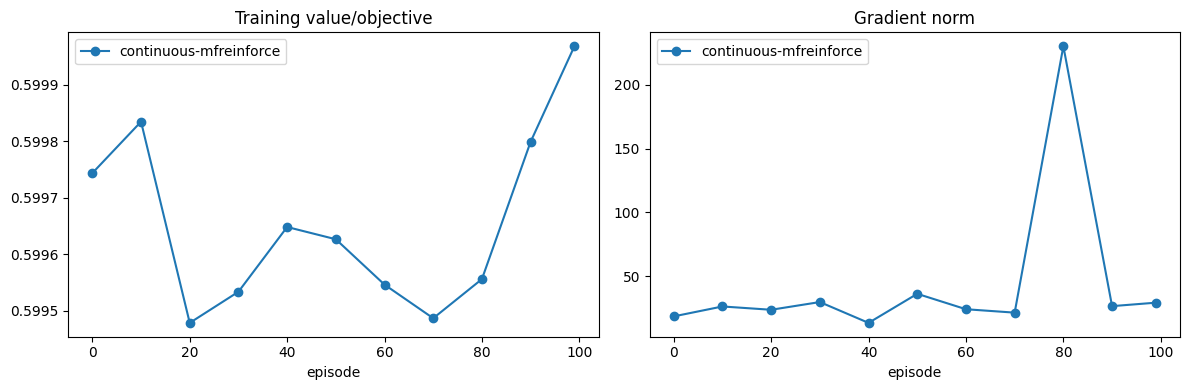

In [5]:
histories = nh.load_training_histories(bundle)
nh.plot_training_comparison(histories)

## Application Diagnostics

Goal: evaluate learned allocations through terminal wealth, risk, and oracle distance.

Reference: optimal curves and policy columns use the closed-form mean-variance portfolio oracle, so the objective gap and efficient-frontier distance are direct correctness checks.

The moment plots show

$$
m_t=\mathbb{E}[W_t],
\qquad
v_t=\operatorname{Var}(W_t),
$$

and the policy panels compare $(k_t,\ell_t)$ with the exact mean-variance oracle. The terminal statistics and efficient-frontier panel summarize the tradeoff in $\mathbb{E}[W_T]$ versus $\operatorname{Var}(W_T)$.

,algorithm,reference_kind,learned_objective,optimal_objective,objective_gap
0,continuous-mfreinforce,closed_form_mean_variance_optimizer,0.599968,0.80247,0.202503


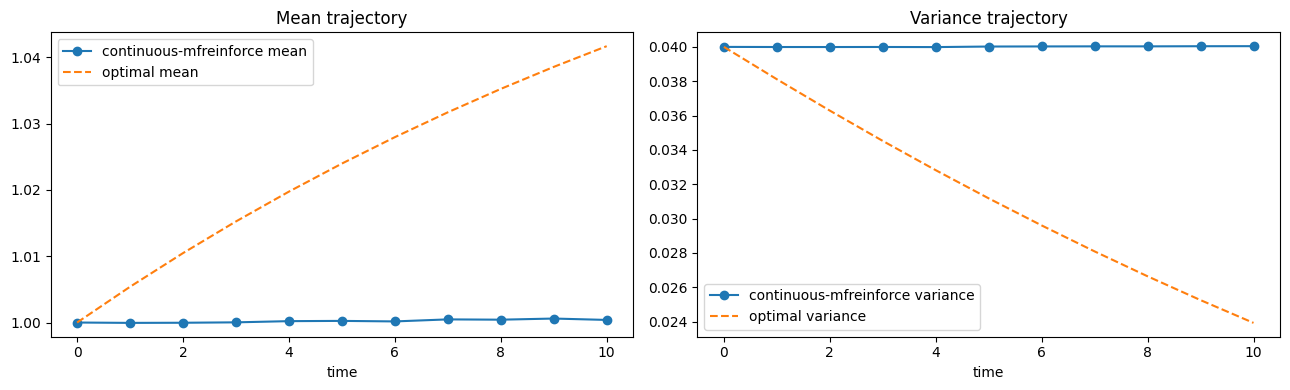

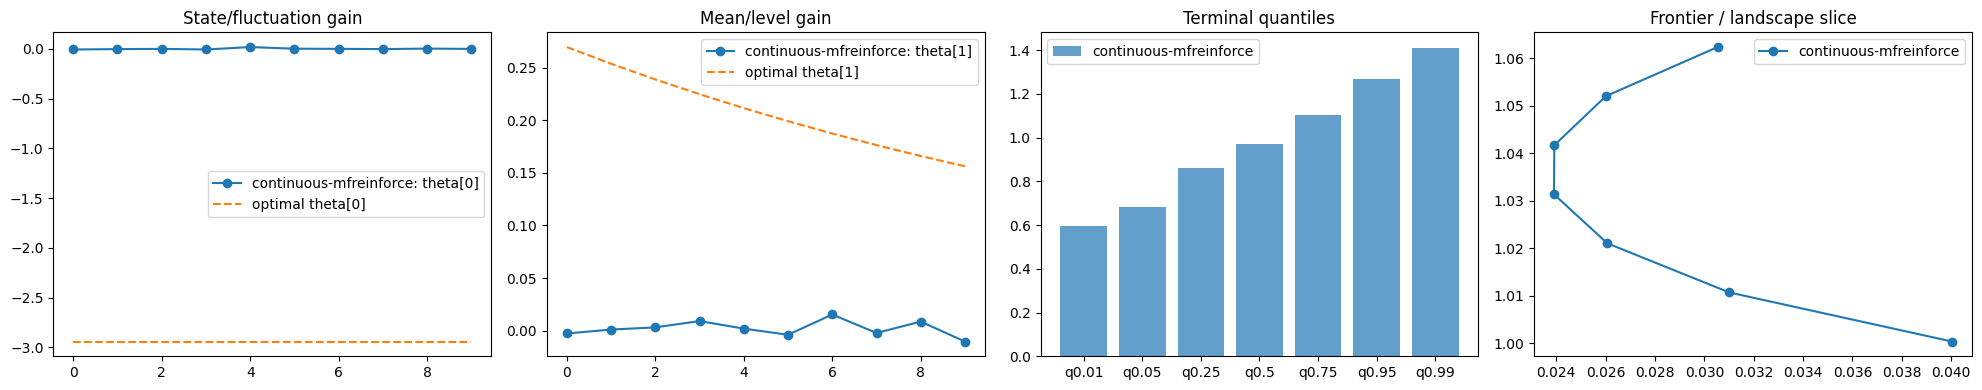

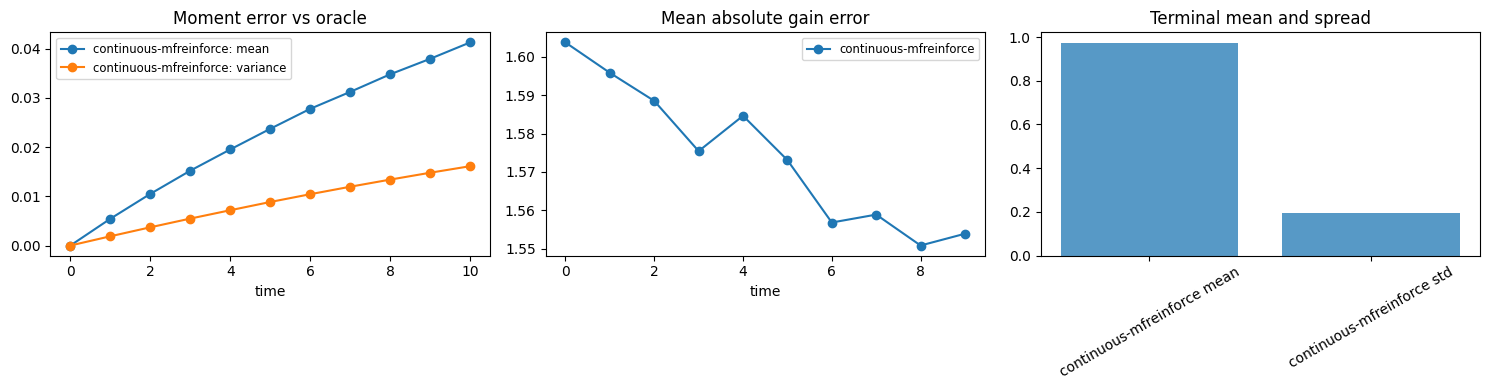

In [6]:
application = nh.load_application_data(bundle)
display(nh.reference_solution_table(ENV_NAME, application))
nh.plot_continuous_time_metrics(application, ENV_NAME)
nh.plot_continuous_policy_and_samples(application, ENV_NAME)
nh.plot_continuous_snapshots(application, ENV_NAME)
nh.plot_continuous_application_details(application, ENV_NAME)

## Universal Diagnostics

Goal: validate the estimator chain before interpreting optimization performance.

The perturbation plots measure empirical geometry,

$$
d(M^\lambda,\mu),
$$

including quantile bands and local log-log slopes. The functional-law plots study

$$
\Gamma(M^\lambda)=(F_1(M^\lambda),\ldots,F_k(M^\lambda)),
\qquad
\frac{\Gamma(M^\lambda)-\Gamma(\mu)}{\lambda},
$$

which is the induced law of population signatures. The score plots check

$$
S_{t,\lambda}^\theta=\nabla_\theta\log q_{t,\lambda}^\theta(M_t),
\qquad \mathbb{E}[S_{t,\lambda}^\theta]\approx 0,
$$

and the gradient plots report bias, variance, MSE, norm ratio, and cosine agreement for an estimator $\widehat g$ against an oracle or reference gradient $g$:

$$
\operatorname{MSE}=\mathbb{E}\|\widehat g-g\|_2^2,
\qquad
\cos(\widehat g,g)=\frac{\widehat g\cdot g}{\|\widehat g\|_2\|g\|_2}.
$$

The sensitivity plots track errors in $D_t=\partial_\theta\Gamma(\mu_t^\theta)$, or in the finite-state case $D_t=\partial_\theta\mu_t^\theta$.

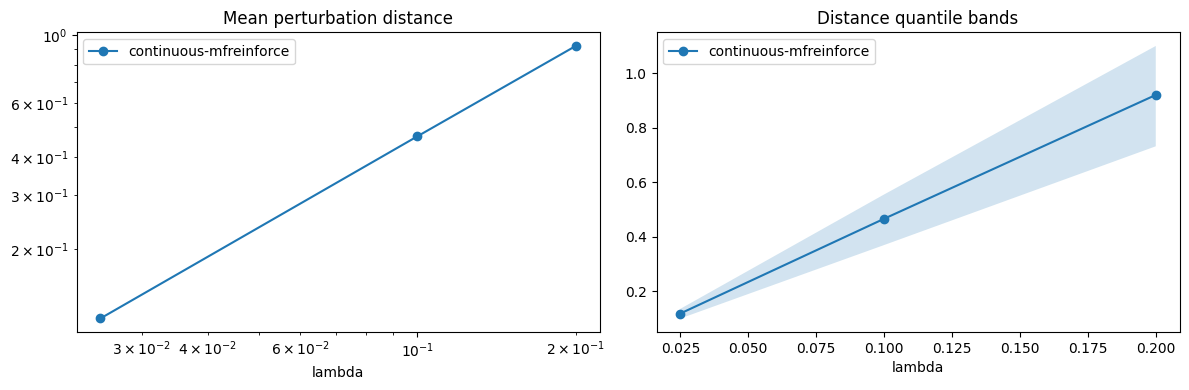

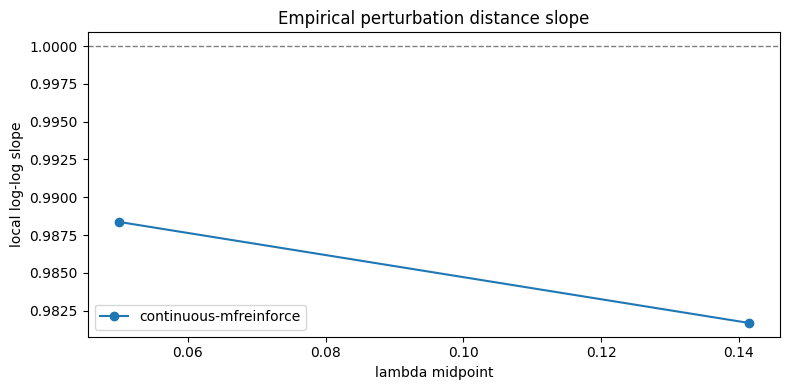

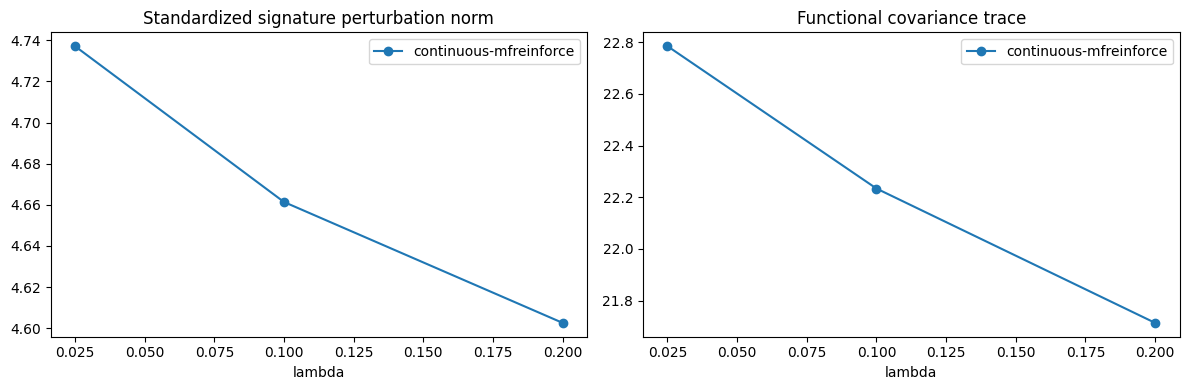

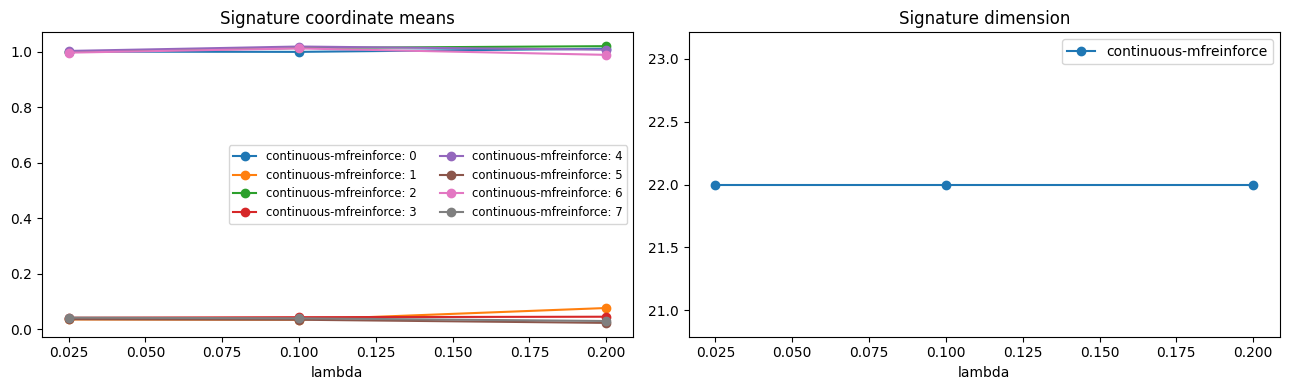

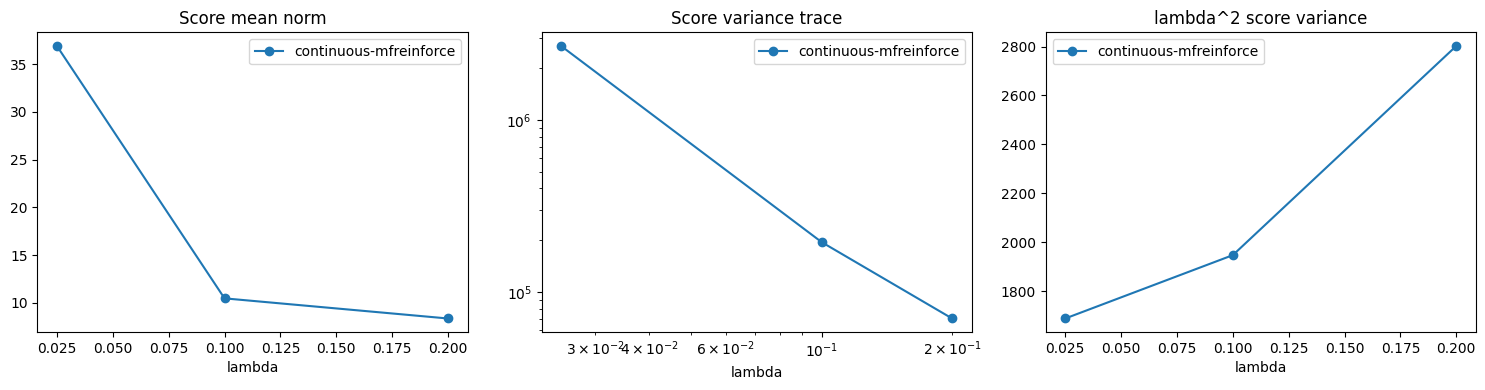

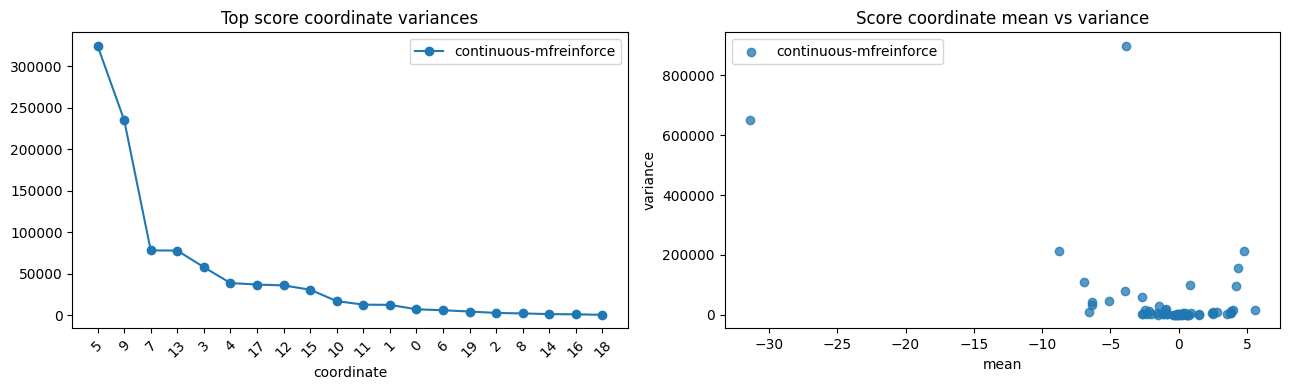

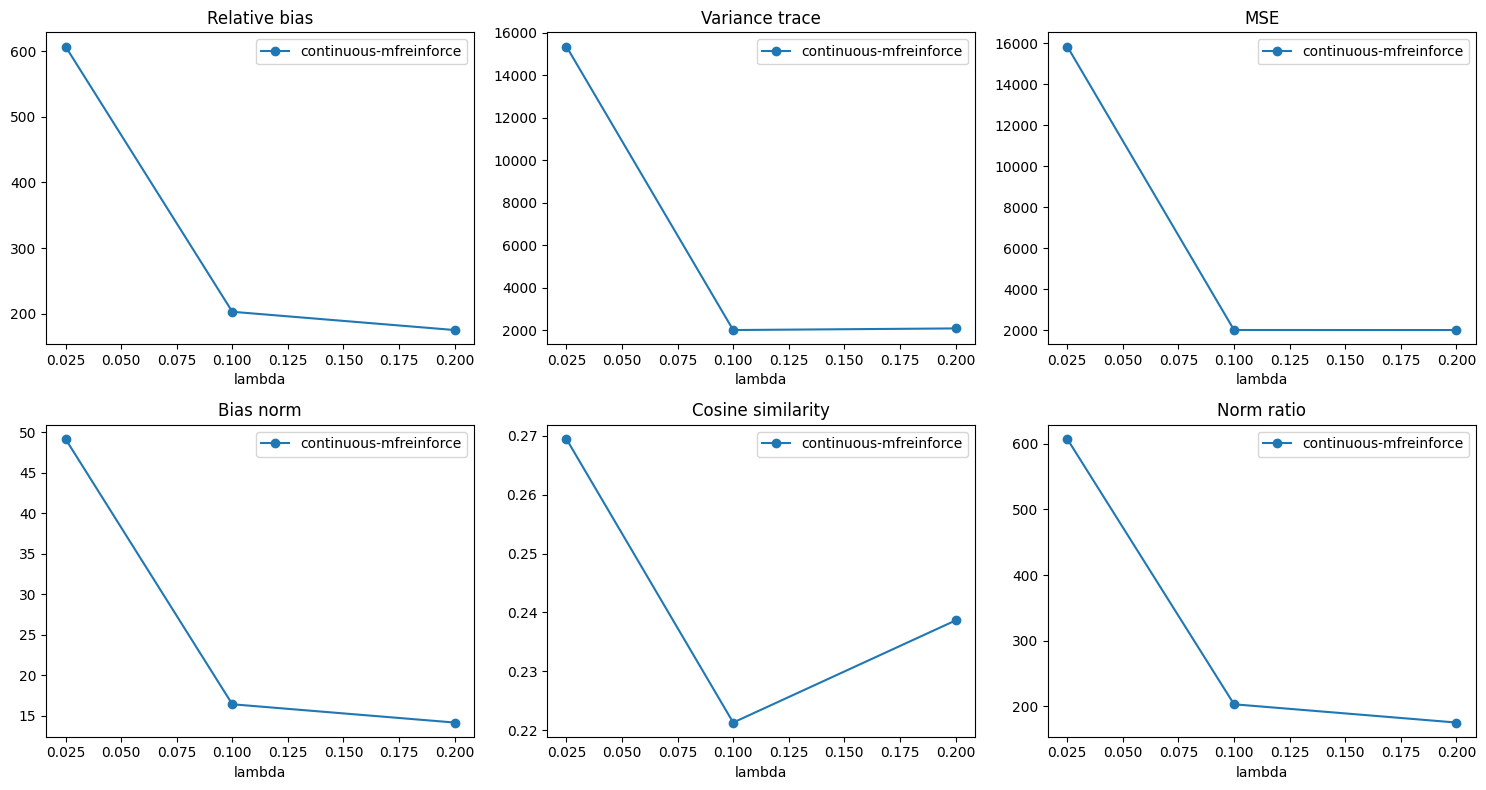

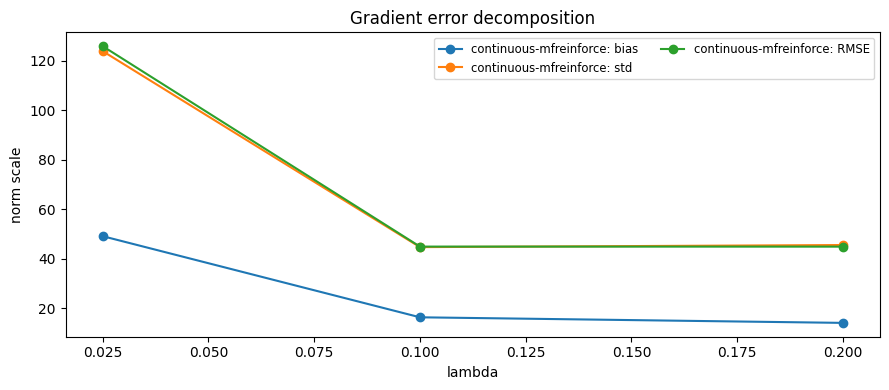

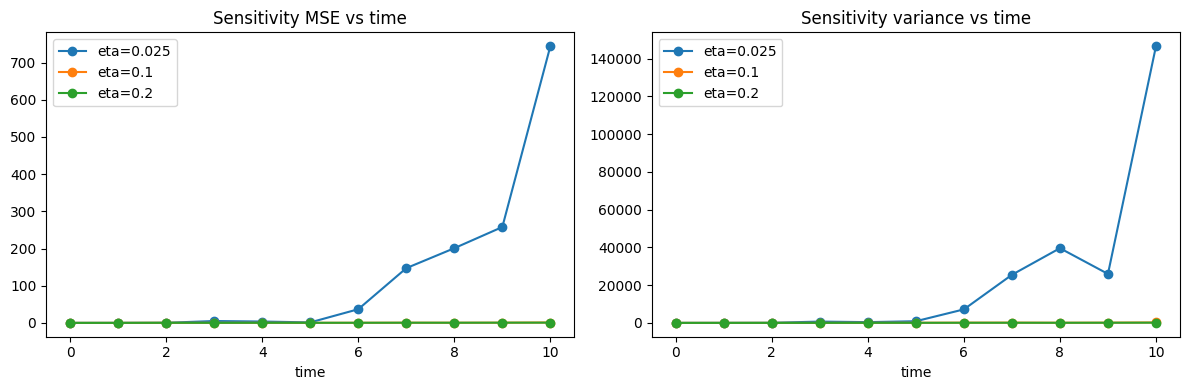

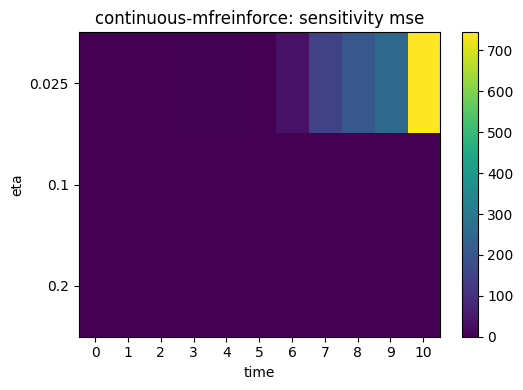

In [7]:
diagnostics = nh.load_diagnostic_data(bundle)
nh.plot_perturbation_geometry(diagnostics)
nh.plot_perturbation_slopes(diagnostics)
nh.plot_functional_law(diagnostics)
nh.plot_functional_signature_means(diagnostics)
nh.plot_score_validation(diagnostics)
nh.plot_score_coordinate_diagnostics(diagnostics)
nh.plot_gradient_validation(diagnostics)
nh.plot_gradient_error_decomposition(diagnostics)
nh.plot_sensitivity_validation(diagnostics)
nh.plot_sensitivity_heatmap(diagnostics)

## Scaling, Budget, And Optimization Summaries

Goal: measure how estimator quality and optimization performance change with simulator budget, auxiliary budget, horizon, and training time.

The budget heatmap varies main and auxiliary samples $(B,n)$ under the approximate cost model

$$
C\approx C_{main}B+C_{aux}n.
$$

The horizon plot studies how gradient error changes with $T$, and the optimization plots compare objective or cost gaps against iteration count, runtime, and simulator-call budget.

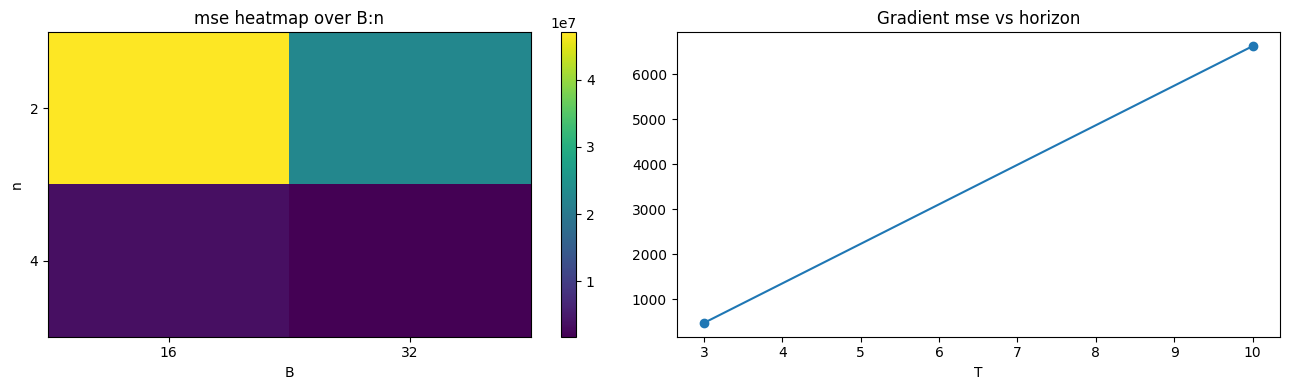

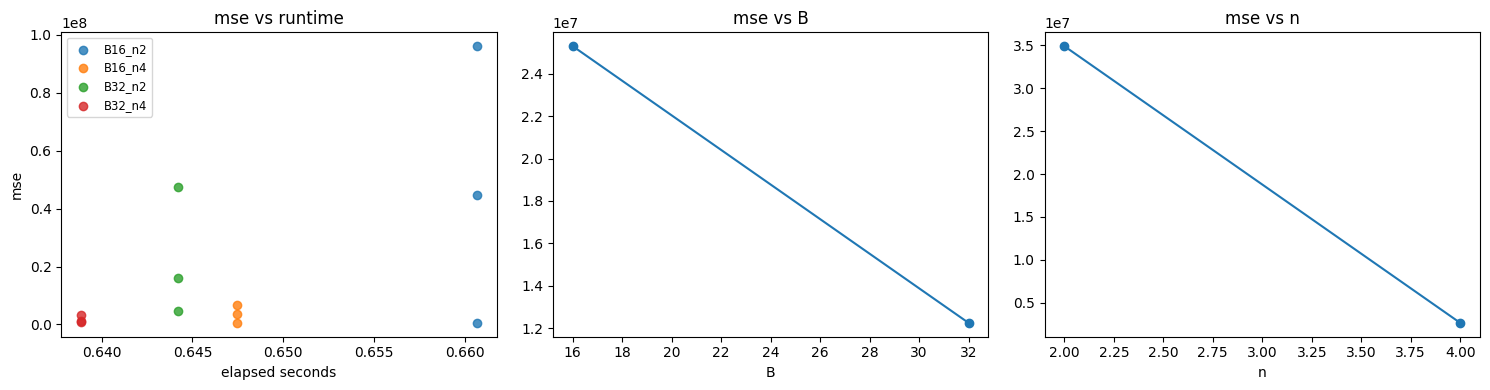

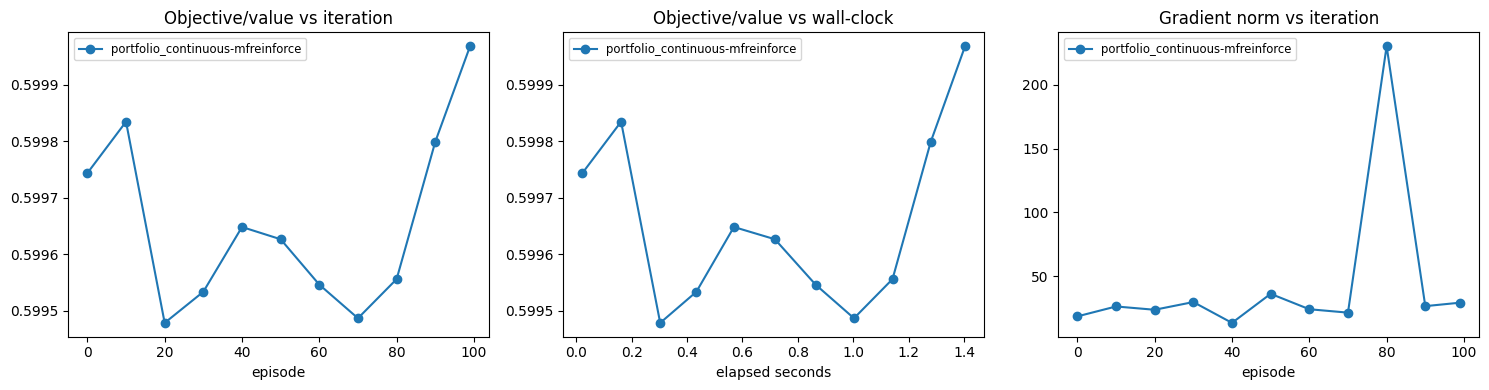

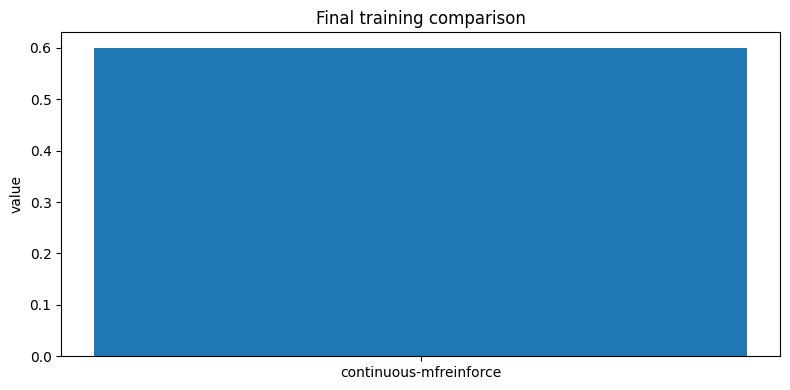

In [8]:
studies = nh.load_study_data(bundle)
grid_metrics = nh.load_study_grid_metrics(bundle)
optimization_history = nh.load_optimization_history(bundle)
nh.plot_budget_and_horizon(studies)
nh.plot_budget_pareto(studies, grid_metrics)
nh.plot_optimization_history(optimization_history)
nh.plot_optimization_summary(studies)

## Raw Tables For Custom Figures

Goal: expose the underlying CSV/JSON artifacts used by the plots so paper figures can be restyled or recomputed without rerunning training.

These tables are not new estimators. They are the saved values for population flows, policies, diagnostics, study grids, histories, and final metrics.

In [9]:
application[nh.CONTINUOUS_ALGORITHM]["time_metrics"].head(), diagnostics[nh.CONTINUOUS_ALGORITHM]["gradient"].head(), studies["budget"].head()

(         env  time      mean  variance  optimal_mean  optimal_variance  \
 0  portfolio     0  1.000000  0.040000      1.000000          0.040000   
 1  portfolio     1  0.999946  0.039993      1.005393          0.038115   
 2  portfolio     2  0.999965  0.039992      1.010468          0.036288   
 3  portfolio     3  1.000027  0.039995      1.015245          0.034521   
 4  portfolio     4  1.000208  0.039989      1.019741          0.032817   
 
    mean_error  variance_error  
 0    0.000000        0.000000  
 1    0.005447        0.001878  
 2    0.010503        0.003704  
 3    0.015218        0.005474  
 4    0.019533        0.007172  ,
    lambda  replications  estimate_norm  variance_trace  \
 0   0.025             8      49.198530    15342.113103   
 1   0.100             8      16.452983     2003.089056   
 2   0.200             8      14.199027     2079.919839   
 
    covariance_largest_eigenvalue  oracle_norm  bias_norm  relative_bias  \
 0                    7818.839068  